<a href="https://colab.research.google.com/github/meheramey/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: NLP and Sequence Modeling Mini Project
**Dataset:** Customer Support Text Classification Dataset  
**Goal:** Classify customer support messages into 3 sentiment categories: positive, neutral, negative  
**Dataset Source:** BITSoM Module 5 - Part 3

In [1]:
# Create results folder
import os
os.makedirs('results', exist_ok=True)
print('results/ folder ready!')

results/ folder ready!


In [2]:
# Install required library for text preprocessing
import subprocess
subprocess.run(['pip', 'install', 'nltk', '-q'])
print('Libraries installed!')

Libraries installed!


In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully!')

TensorFlow version: 2.20.0
All libraries imported successfully!


---
## Task 1: Dataset Understanding

In [4]:
# Load the dataset
df = pd.read_csv('customer_support_text_classification.csv')

print('=== DATASET OVERVIEW ===')
print(f'Number of Records: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')
print(f'Columns: {list(df.columns)}')

=== DATASET OVERVIEW ===
Number of Records: 1500
Number of Columns: 6
Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']


In [5]:
# First 5 rows
print('=== SAMPLE RECORDS ===')
df.head()

=== SAMPLE RECORDS ===


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [6]:
# Sample text records
print('=== SAMPLE CUSTOMER MESSAGES ===')
for i in range(5):
    print(f'[{df["sentiment_label"][i].upper()}] {df["customer_message"][i]}')
    print()

=== SAMPLE CUSTOMER MESSAGES ===
[NEUTRAL] I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

[NEUTRAL] I need information about the payment process.

[POSITIVE] The refund process was fast and convenient. I appreciate the quick response.

[NEGATIVE] My refund is still pending and this experience is frustrating. My ticket number is 33927.

[NEUTRAL] Please tell me how to update my account details.



=== TARGET LABELS ===
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average text length: 12.72 words
Min text length: 7 words
Max text length: 26 words


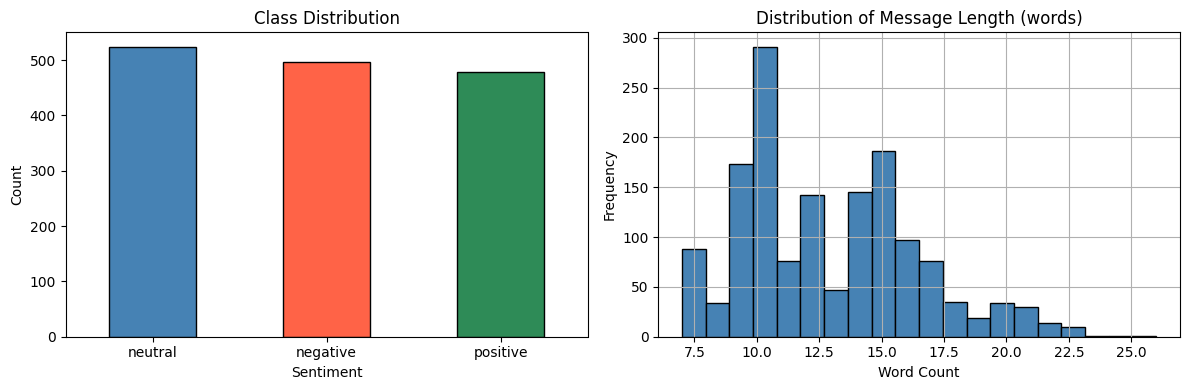

Plot saved!


In [7]:
# Target labels and class distribution
print('=== TARGET LABELS ===')
print(df['sentiment_label'].value_counts())

# Average text length
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))
print(f'\nAverage text length: {df["text_length"].mean():.2f} words')
print(f'Min text length: {df["text_length"].min()} words')
print(f'Max text length: {df["text_length"].max()} words')

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato', 'seagreen'],
    edgecolor='black'
)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['text_length'].hist(ax=axes[1], bins=20, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Message Length (words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

---
## Task 2: Text Preprocessing

In [8]:
# Text cleaning function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = str(text).lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['cleaned_message'] = df['customer_message'].apply(clean_text)

# Show before and after
print('=== TEXT PREPROCESSING RESULTS ===')
for i in range(3):
    print(f'ORIGINAL : {df["customer_message"][i]}')
    print(f'CLEANED  : {df["cleaned_message"][i]}')
    print()

=== TEXT PREPROCESSING RESULTS ===
ORIGINAL : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
CLEANED  : need information payment process ticket number please respond soon possible

ORIGINAL : I need information about the payment process.
CLEANED  : need information payment process

ORIGINAL : The refund process was fast and convenient. I appreciate the quick response.
CLEANED  : refund process fast convenient appreciate quick response



---
## Task 3: Text Vectorization

In [9]:
# Why text must be converted to vectors?
print('=== WHY TEXT VECTORIZATION IS NEEDED ===')
print('''
Machine learning models only understand numbers, not raw text.
Text vectorization converts words into numerical representations
so that mathematical operations (like dot products, gradients)
can be performed on them.

Without vectorization:
  "I love this product" -> cannot be processed by a model

With TF-IDF vectorization:
  "I love this product" -> [0.0, 0.42, 0.0, 0.71, 0.0, ...]
''')

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['sentiment_label'])
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Train-test split
X = df['cleaned_message']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

=== WHY TEXT VECTORIZATION IS NEEDED ===

Machine learning models only understand numbers, not raw text.
Text vectorization converts words into numerical representations
so that mathematical operations (like dot products, gradients)
can be performed on them.

Without vectorization:
  "I love this product" -> cannot be processed by a model

With TF-IDF vectorization:
  "I love this product" -> [0.0, 0.42, 0.0, 0.71, 0.0, ...]

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Training samples: 1200
Testing samples:  300


In [10]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('=== TF-IDF VECTORIZATION ===')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Training matrix shape: {X_train_tfidf.shape}')
print(f'Testing matrix shape:  {X_test_tfidf.shape}')
print('\nTF-IDF converts each message into a vector of 5000 features')
print('Each feature represents the importance of a word/phrase in the document')

=== TF-IDF VECTORIZATION ===
Vocabulary size: 427
Training matrix shape: (1200, 427)
Testing matrix shape:  (300, 427)

TF-IDF converts each message into a vector of 5000 features
Each feature represents the importance of a word/phrase in the document


---
## Task 4: Baseline Model

In [11]:
# Logistic Regression with TF-IDF (Baseline Model)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print('=== BASELINE MODEL: Logistic Regression + TF-IDF ===')
print(f'Training Accuracy: {lr_model.score(X_train_tfidf, y_train)*100:.2f}%')
print(f'Testing Accuracy:  {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== BASELINE MODEL: Logistic Regression + TF-IDF ===
Training Accuracy: 100.00%
Testing Accuracy:  100.00%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



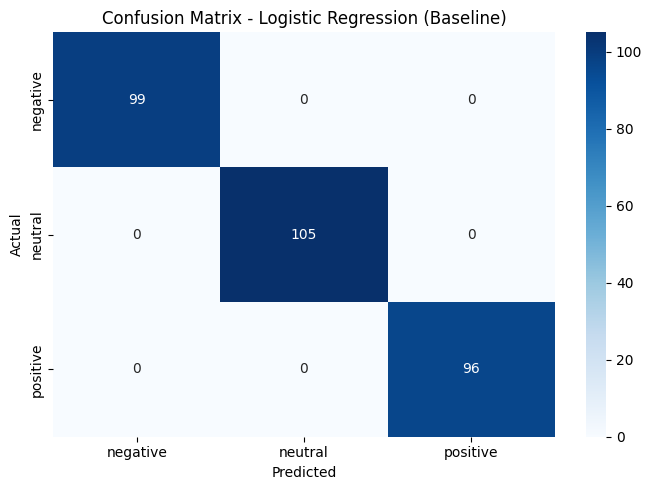

Confusion matrix saved!


In [12]:
# Confusion Matrix - Baseline Model
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved!')

---
## Task 5: Sequence Model - LSTM

In [13]:
# Tokenizer-based sequence preparation for LSTM
MAX_WORDS = 5000   # Vocabulary size
MAX_LEN   = 50     # Max sequence length (padding/truncating)

# Tokenize text
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print('=== SEQUENCE PREPARATION ===')
print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape:  {X_test_pad.shape}')
print(f'\nSample sequence (first message):')
print(f'Text: {X_train.iloc[0]}')
print(f'Sequence: {X_train_pad[0]}')

=== SEQUENCE PREPARATION ===
Vocabulary size: 147
X_train_pad shape: (1200, 50)
X_test_pad shape:  (300, 50)

Sample sequence (first message):
Text: confirm whether ticket assigned please respond soon possible
Sequence: [65 66  2 67  4  5  6  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]


In [14]:
# One-hot encode labels for LSTM
y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=3)

# Build LSTM Model
tf.random.set_seed(42)

lstm_model = keras.Sequential([
    # Input
    layers.Input(shape=(MAX_LEN,)),

    # Embedding Layer - converts word indices to dense vectors
    layers.Embedding(input_dim=MAX_WORDS, output_dim=64),

    # LSTM Layer - learns sequential patterns in text
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),

    # Dense Layer
    layers.Dense(32, activation='relu'),

    # Output Layer - 3 classes (positive, neutral, negative)
    layers.Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,203 (1.35 MB)

 Trainable params: 355,203 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train LSTM Model
history = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print('\nLSTM training complete!')

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3354 - loss: 1.1007 - val_accuracy: 0.3042 - val_loss: 1.1008
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.3302 - loss: 1.0993 - val_accuracy: 0.3375 - val_loss: 1.1008
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3365 - loss: 1.0981 - val_accuracy: 0.3375 - val_loss: 1.1011
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3375 - loss: 1.0989 - val_accuracy: 0.3375 - val_loss: 1.1010
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3396 - loss: 1.0987 - val_accuracy: 0.3042 - val_loss: 1.1020
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3302 - loss: 1.0985 - val_accuracy: 0.3375 - val_loss: 1.1005
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3562 - loss: 1.0978 - val_accuracy: 0.3375 - val_loss: 1.1013
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3417 - loss: 1.0984 - val_accuracy: 0.3375 - v

In [16]:
# Evaluate LSTM
test_loss, test_acc = lstm_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f'LSTM Test Accuracy: {test_acc*100:.2f}%')
print(f'LSTM Test Loss:     {test_loss:.4f}')

# LSTM predictions
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)
print('\n=== LSTM CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

LSTM Test Accuracy: 35.00%
LSTM Test Loss:     1.0981
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

=== LSTM CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        99
     neutral       0.35      1.00      0.52       105
    positive       0.00      0.00      0.00        96

    accuracy                           0.35       300
   macro avg       0.12      0.33      0.17       300
weighted avg       0.12      0.35      0.18       300



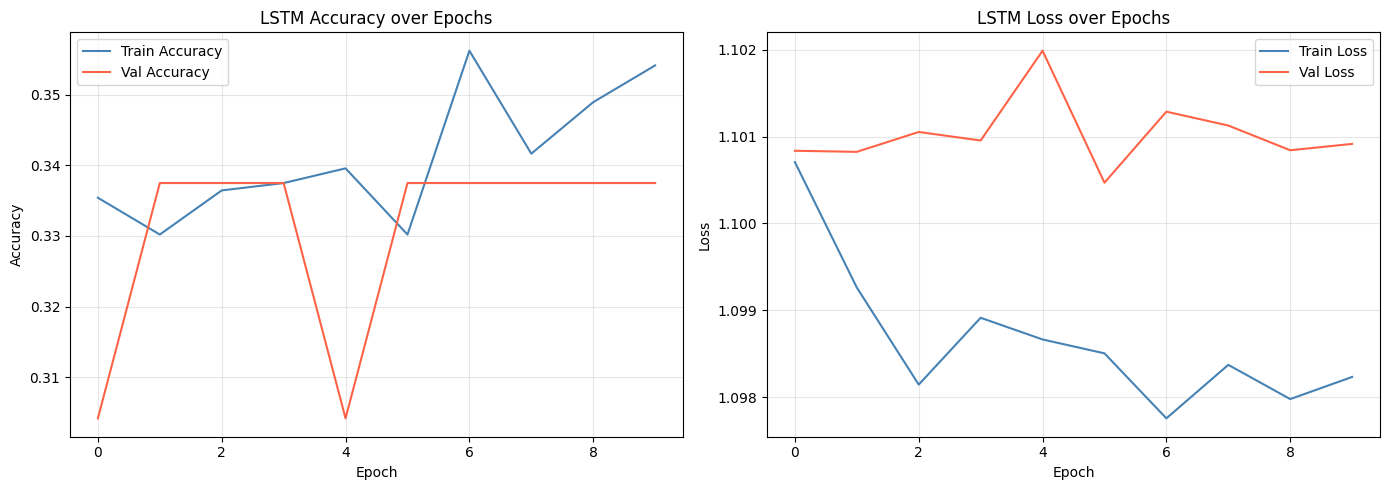

LSTM training curves saved!


In [17]:
# Plot LSTM Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[0].set_title('LSTM Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[1].set_title('LSTM Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('LSTM training curves saved!')

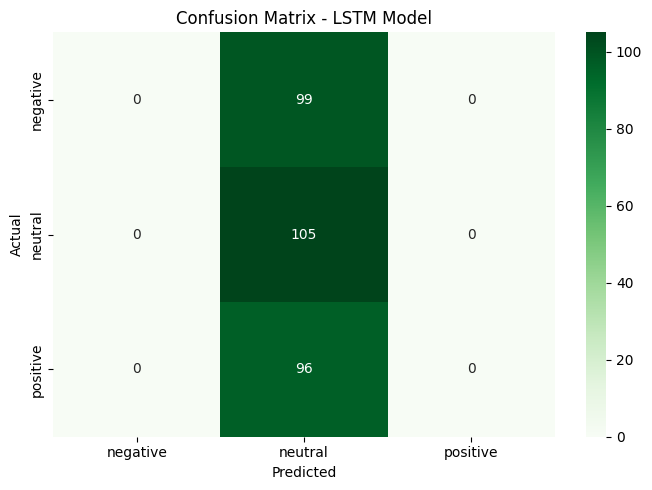

LSTM confusion matrix saved!


In [18]:
# Confusion Matrix - LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - LSTM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('LSTM confusion matrix saved!')

In [19]:
# Model Comparison - Baseline vs LSTM
lr_acc   = accuracy_score(y_test, y_pred_lr) * 100
lstm_acc = test_acc * 100

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'LSTM (Embedding + Sequence)'],
    'Vectorization': ['TF-IDF', 'Tokenizer + Embedding'],
    'Test Accuracy (%)': [round(lr_acc, 2), round(lstm_acc, 2)]
})

print('=== MODEL COMPARISON ===')
print(comparison_df.to_string(index=False))
comparison_df.to_csv('results/model_evaluation.csv', index=False)
print('\nComparison saved!')

=== MODEL COMPARISON ===
                       Model         Vectorization  Test Accuracy (%)
Logistic Regression (TF-IDF)                TF-IDF              100.0
 LSTM (Embedding + Sequence) Tokenizer + Embedding               35.0

Comparison saved!


In [20]:
# Sample Predictions
sample_texts = [
    "I am very happy with the service, it was excellent!",
    "The product stopped working after two days, very disappointing.",
    "My order was delivered on time."
]

print('=== SAMPLE PREDICTIONS ===')
results_list = []
for text in sample_texts:
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    pred = np.argmax(lstm_model.predict(padded, verbose=0), axis=1)[0]
    label = le.classes_[pred]
    print(f'Text: {text}')
    print(f'Predicted Sentiment: {label.upper()}')
    print()
    results_list.append({'text': text, 'predicted_sentiment': label})

# Save sample predictions
with open('results/sample_predictions.txt', 'w') as f:
    for r in results_list:
        f.write(f"Text: {r['text']}\n")
        f.write(f"Predicted: {r['predicted_sentiment'].upper()}\n\n")
print('Sample predictions saved!')

=== SAMPLE PREDICTIONS ===
Text: I am very happy with the service, it was excellent!
Predicted Sentiment: NEUTRAL

Text: The product stopped working after two days, very disappointing.
Predicted Sentiment: NEUTRAL

Text: My order was delivered on time.
Predicted Sentiment: NEUTRAL

Sample predictions saved!


---
## Task 6: Attention and Transformer Reflection

### Why do RNNs Struggle with Long-Term Dependencies?
RNNs process text word by word, passing a hidden state from one step to the next. For long sentences, the information from early words gets diluted as it passes through many steps. By the time the model reaches the end of a long sentence, it has largely "forgotten" what was said at the beginning. This is called the **vanishing gradient problem** — gradients become very small during backpropagation through many time steps, making it hard to learn long-range connections.

### How do LSTMs Help with Memory?
LSTMs (Long Short-Term Memory networks) solve the vanishing gradient problem by introducing three **gates**:
- **Forget Gate:** Decides what information to discard from memory
- **Input Gate:** Decides what new information to store in memory
- **Output Gate:** Decides what information to pass to the next step

This gating mechanism allows LSTMs to selectively remember important information from earlier in the sequence, even across many time steps.

### What Does Attention Solve in Sequence-to-Sequence Tasks?
In tasks like machine translation (e.g., English to French), the encoder must compress the entire input sentence into one fixed-size vector — which loses information for long sentences. **Attention** allows the decoder to directly "look at" all encoder outputs and focus on the most relevant words at each decoding step. For example, when translating "bank" the model can attend to surrounding words to decide if it means a financial institution or a river bank.

### Why are Transformers Important in Modern NLP and Generative AI?
Transformers replaced RNNs/LSTMs as the dominant architecture because:
- **Parallel processing:** Unlike RNNs, transformers process all words simultaneously — much faster training
- **Self-attention:** Every word attends to every other word in the sequence — captures global context
- **Scalability:** Can be scaled to billions of parameters (GPT, BERT, LLaMA)
- **Transfer learning:** Pre-trained transformers can be fine-tuned for many tasks with minimal data

Models like **GPT-4, BERT, and Claude** are all built on the transformer architecture, making it the foundation of modern Generative AI.